In [1]:
from pathlib import Path
from src.flow_models.config import Config
from src.flow_models.trainers.trainer import Trainer
import argparse
import sys

import matplotlib.pyplot as plt

from jax import config
import jax.numpy as jnp
import jax.random as jr

config.update('jax_cuda_visible_devices', '0')

class Args(argparse.Namespace):
  data_path = 'data/two_moons.pkl'
  model_type = 'ct'
  input_shape = None
  output_shape = None
  latent_shape = None
  recon_weight = 0.0
  reg_weight = 0.0
  recon_loss_type = 'mse'
  crn_type = None
  network_type = None
  hidden_dims = None
  encoder_model_type = 'identity' # 'mlp', 'mlp_normal', 'resnet', 'resnet_normal', 'identity', 'linear'
  decoder_model_type = 'identity' # 'mlp', 'resnet', 'identity'
  decoder_type = 'linear'
  noise_schedule = 'network' # 'constant', 'linear', 'cosine', 'exponential', 'cauchy', 'laplace', 'logistic', 'quadratic', 'polynomial', 'network'
  noise_schedule_learnable = True

args = Args()
key = jr.PRNGKey(137)

In [2]:
import pickle
def load_data(data_path: str):
    """Load dataset from pickle file.
    
    Expected format: dict with 'train' and 'val' keys, each containing 'x' and 'y' arrays.
    """
    with open(data_path, 'rb') as f:
        data = pickle.load(f)
    x_train = jnp.array(data['train']['x'])
    y_train = jnp.array(data['train']['y'])
    x_val = jnp.array(data['val']['x'])
    y_val = jnp.array(data['val']['y'])
    
    return x_train, y_train, x_val, y_val

In [10]:
config_file = 'examples/two_moons/config.yaml'
config_path = Path(config_file)
loaded_config = Config.load_yaml(config_file)
base_config = Config.merge_with_defaults(loaded_config)

x_train, y_train, x_val, y_val = load_data(args.data_path)
train_x, train_y = y_train, x_train
val_x, val_y = y_val, x_val
x_sample = train_x[0]
y_sample = train_y[0]

num_gen = val_y.shape[0]

def make_trainer(args, seed):
    config = base_config.override_from_args(args, args.model_type, False)

    trainer = Trainer(
        config=config,
        learning_rate=5e-3,
        optimizer_name='adamw',
        seed=seed,
        warmup_steps=0,
        model_type=args.model_type
    )

    trainer.initialize(x_sample, y_sample)

    return trainer

def run_experiment(key, args, train_x, train_y, val_x, val_y):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
    for i, ns in enumerate(['linear', 'exponential', 'sigmoid', 'network']):
        for j, learn in enumerate([True, False]):
            args.noise_schedule = ns
            args.noise_schedule_learnable = learn

            key, _key = jr.split(key)

            trainer = make_trainer(args, _key[0].item())

            history = trainer.train(
                x_data=train_x,
                y_data=train_y,
                num_epochs=200,
                batch_size=512,
                validation_data=(val_x, val_y),
                dropout_epochs=0
            )

            key, _key = jr.split(key)
            y_gen = trainer.conditional_generate(val_x, num_steps=200, prng_key=key)

            axes[j, i].scatter(y_gen[:, 0], y_gen[:, 1], c=val_x.argmax(-1))

            if args.no_noise_schedule:
                axes[j, i].set_title(f'Seed={i + j}', fontsize=10)
            else:
                axes[j, i].set_title(f'NS={ns}, LRN={learn}', fontsize=10)

    fig.tight_layout()


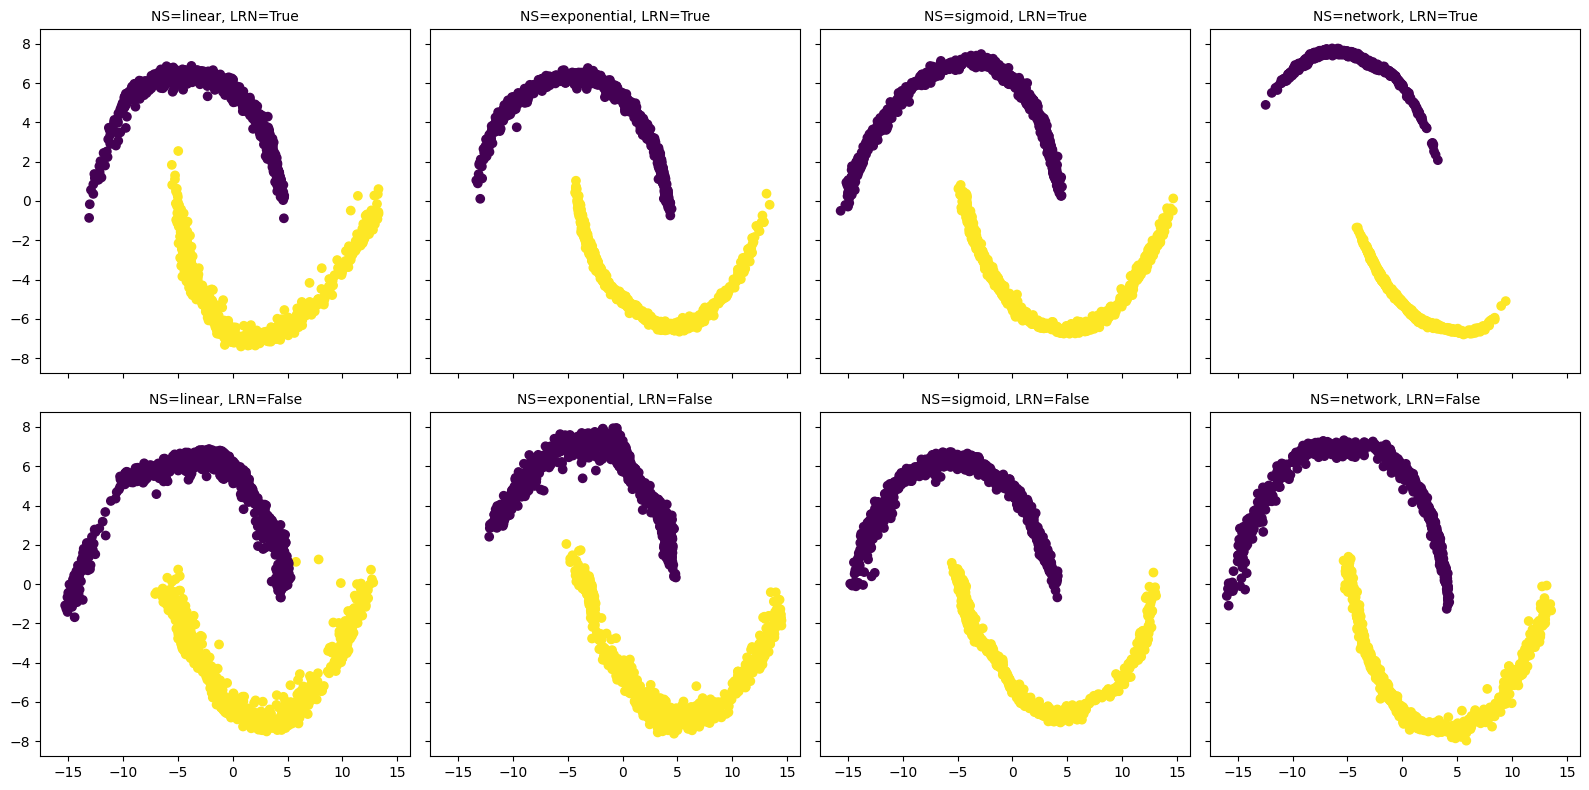

In [4]:
run_experiment(key, args, train_x, train_y, val_x, val_y)

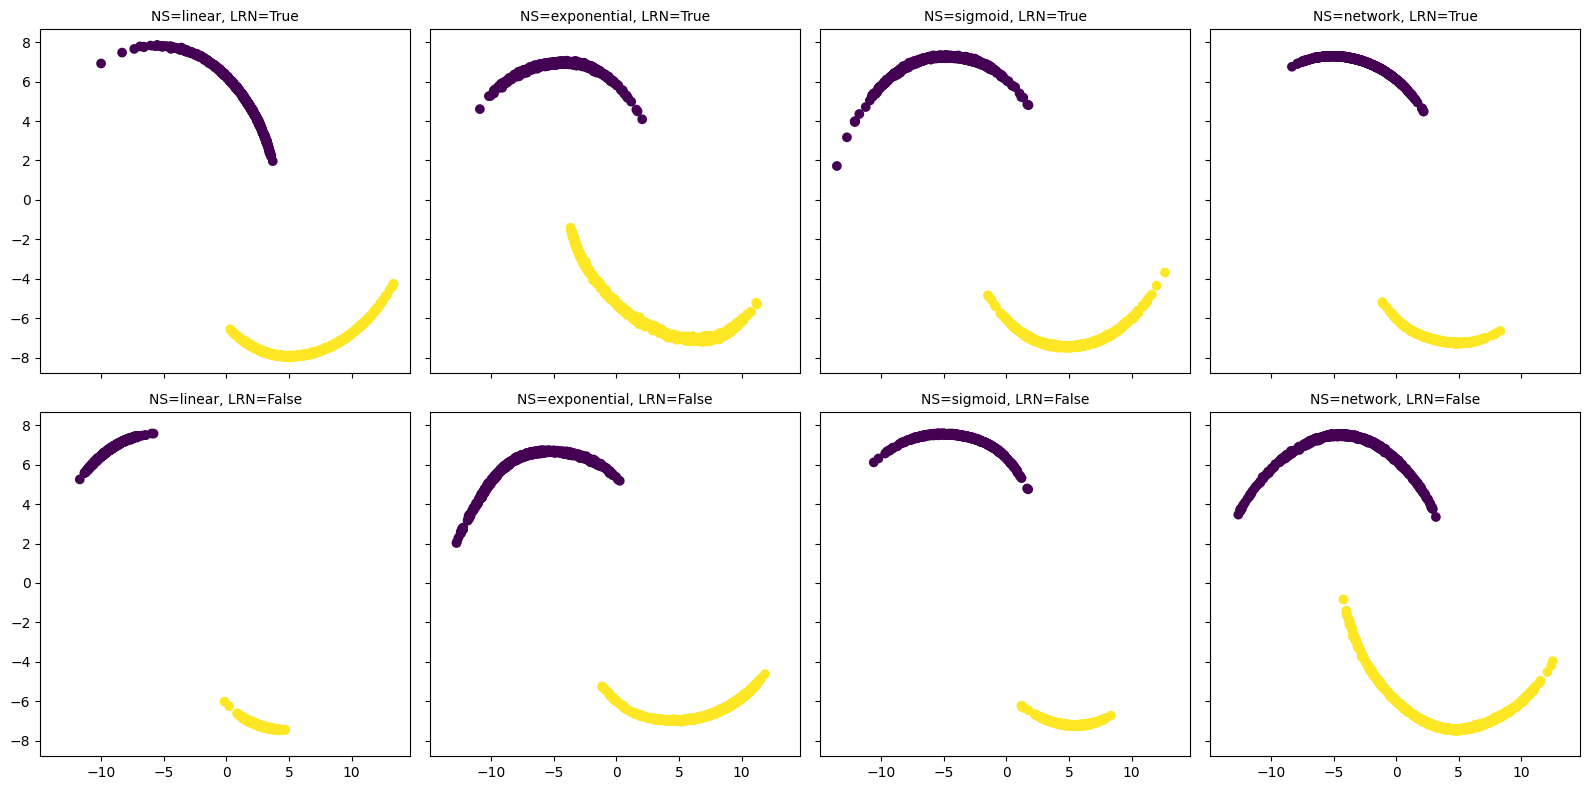

In [5]:
args.encoder_model_type = 'mlp'
args.decoder_model_type = 'mlp'
run_experiment(key, args, train_x, train_y, val_x, val_y)

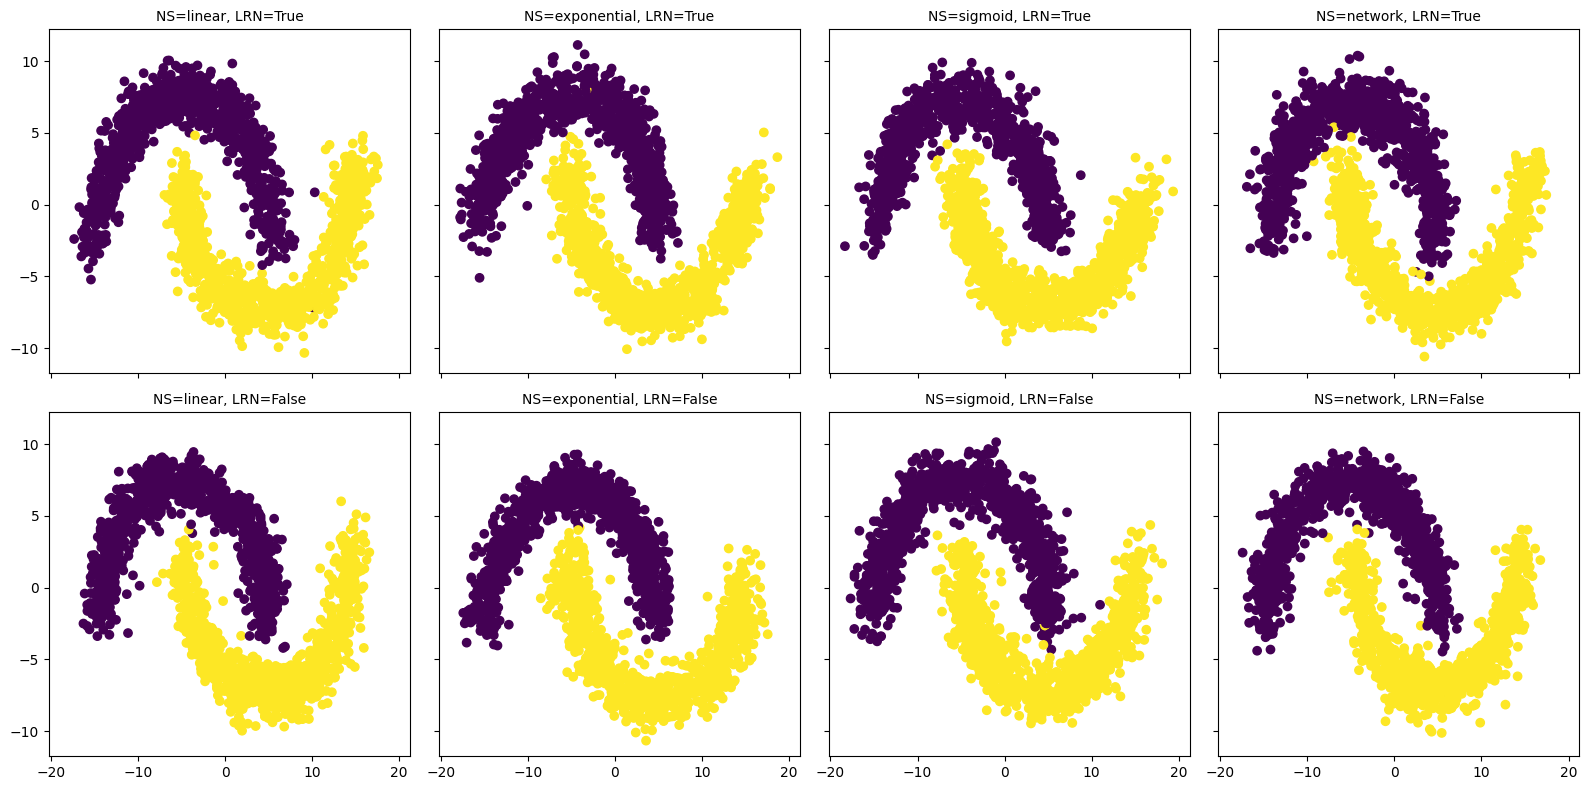

In [6]:
args.model_type = 'flow_matching'
args.encoder_model_type = 'identity'
args.decoder_model_type = 'identity'
args.recon_weight = 1.0
args.vae_weight = 0.0
run_experiment(key, args, train_x, train_y, val_x, val_y)

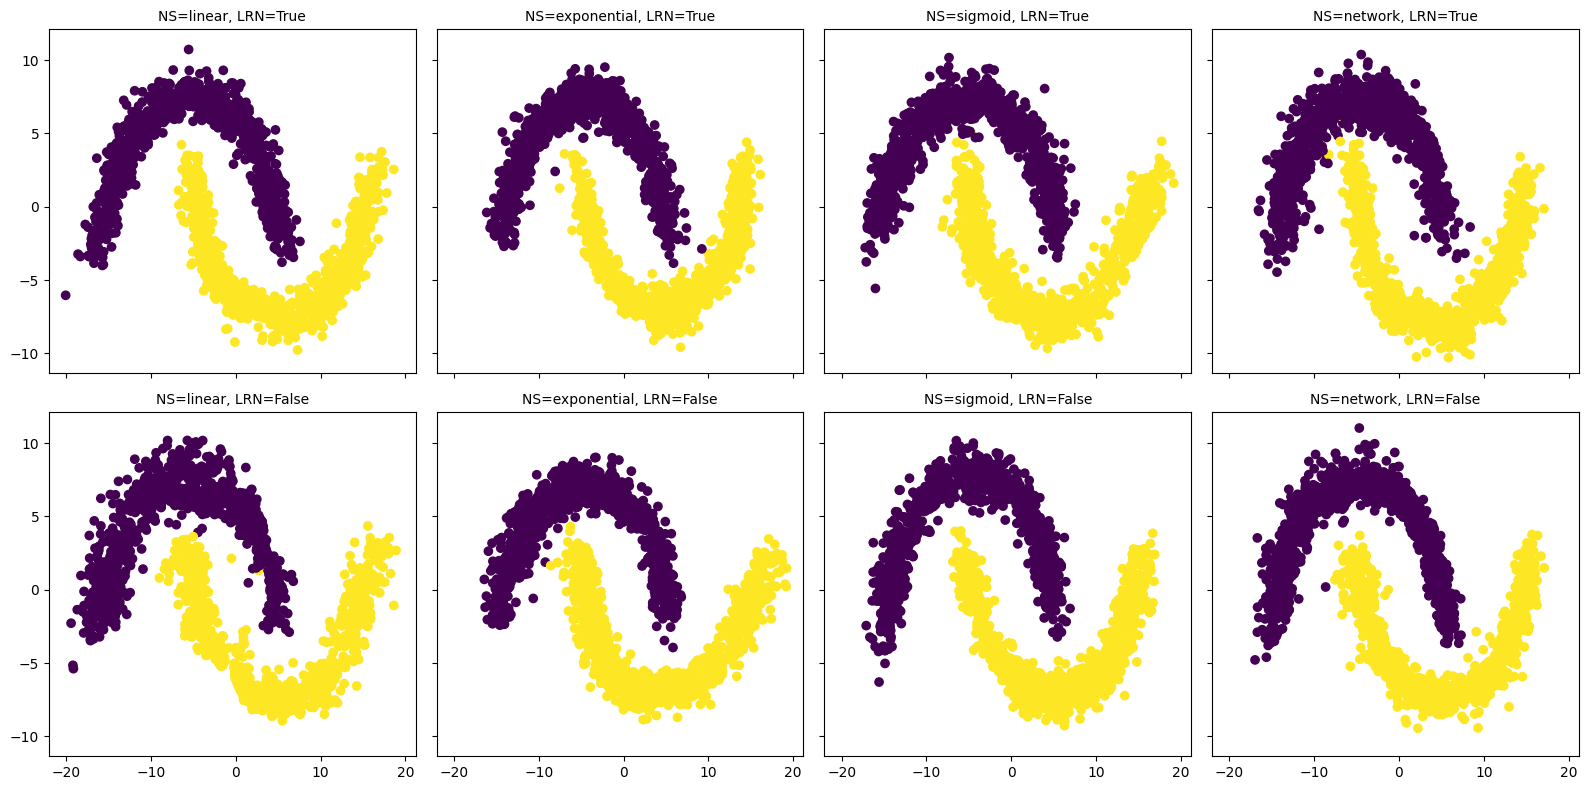

In [7]:
args.model_type = 'flow_matching'
args.encoder_model_type = 'mlp'
args.decoder_model_type = 'mlp'
args.recon_weight = 1.0
args.vae_weight = 0.0
run_experiment(key, args, train_x, train_y, val_x, val_y)

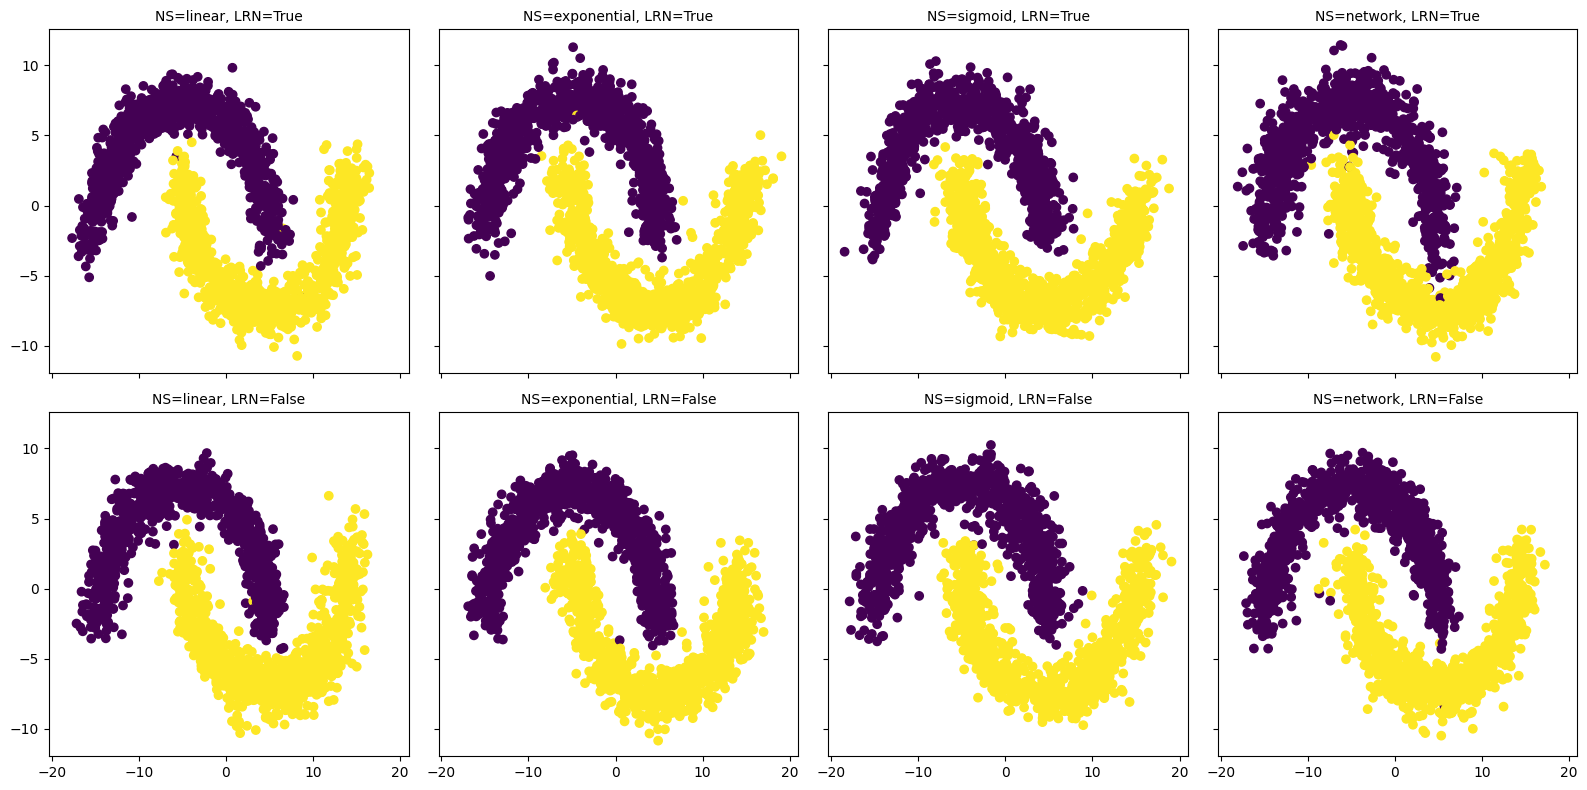

In [8]:
args.model_type = 'flow_matching'
args.encoder_model_type = 'identity'
args.decoder_model_type = 'identity'
args.recon_weight = 0.0
args.vae_weight = 0.0
run_experiment(key, args, train_x, train_y, val_x, val_y)

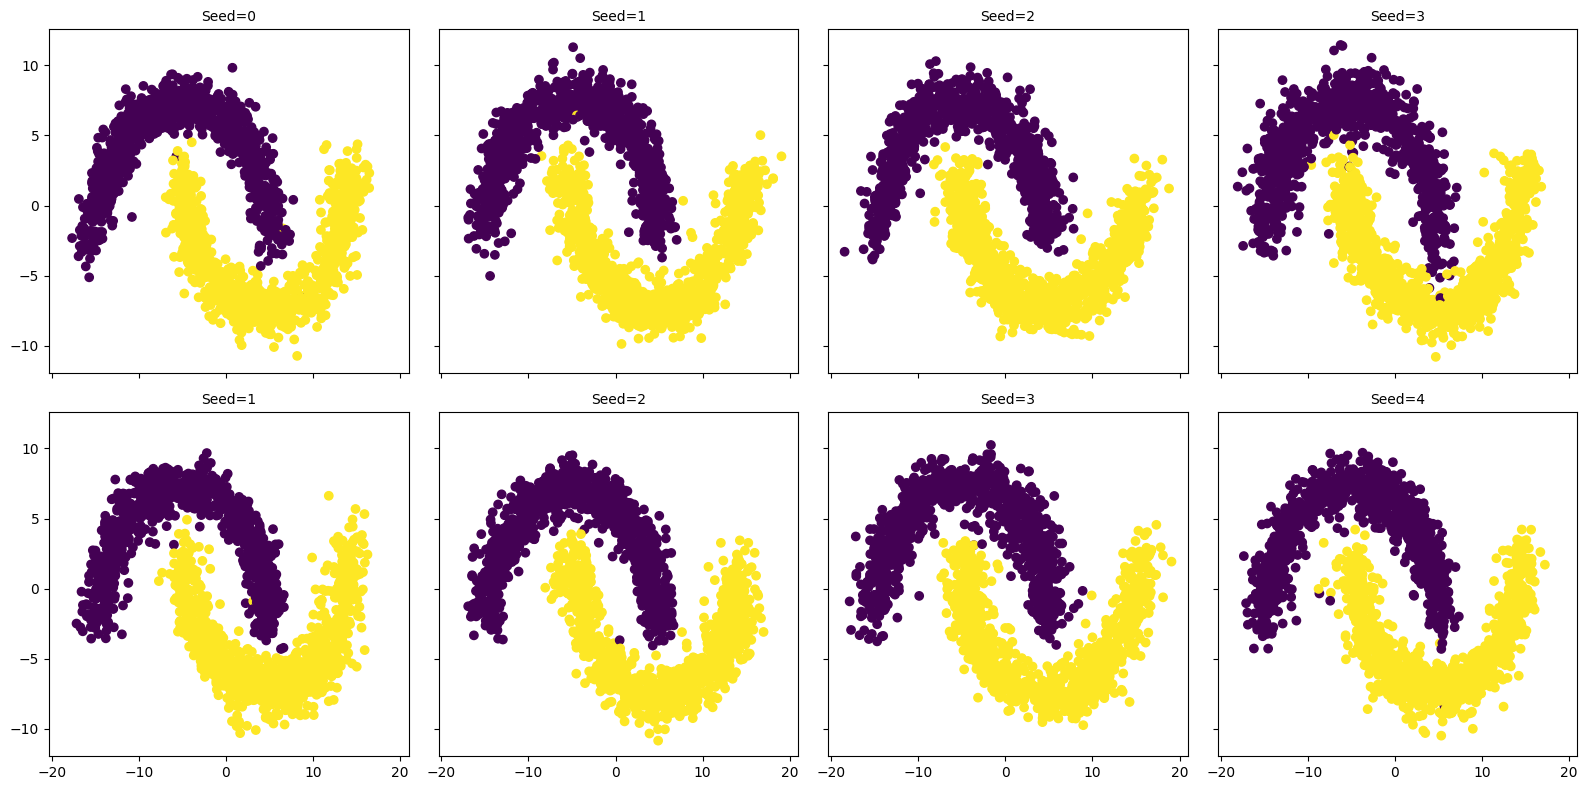

In [11]:
args.model_type = 'flow_matching'
args.encoder_model_type = 'identity'
args.decoder_model_type = 'identity'
args.recon_weight = 0.0
args.vae_weight = 0.0
args.no_noise_schedule = True
run_experiment(key, args, train_x, train_y, val_x, val_y)